# 02 - Forecasting: static vs adaptive (Phase 3)

**Question:** when a structural break has been detected, does retraining on the post-break window improve forecasts compared with a model trained on all history?

**Design**
* 726 CA AX/AY items, daily sales aggregated across CA stores, 28-day horizon.
* Rolling-origin backtest: 7 origins, 28 days apart. Origin 0 (2015-11-08) is a **warm-up** whose errors are only used to seed uncertainty bands and safety stock in notebook 03. **Origins 1-6 (test days 2015-12-07 to 2016-05-22) are the evaluation set.**
* Models: seasonal naive (baseline), ETS (Holt-Winters, damped additive trend + weekly seasonality), global LightGBM (lags ≥28, rolling means, price, calendar, SNAP), TSB for the intermittent items (Syntetos-Boylan ADI > 1.32).
* **No lookahead:** the CUSUM threshold is calibrated on data before origin 0; at each origin, break detection sees only full weeks up to that origin.
* Variants: **static** = all history; **adaptive** = items with a detected break train from the most recent estimated change week; **placebo** = items *without* a break get a random truncation with the same window-length distribution. The placebo tests whether any gain comes from break detection or simply from training on recent data.
* Metric: MASE (seasonal-naive in-sample scale, computed on all history up to the origin, so the same denominator is used for every variant). Item-level WRMSSE (dollar-weighted) as a secondary metric.

In [1]:
import os, sys, time
sys.path.append('../src')
os.environ['PYTHONPATH'] = os.path.abspath('../src')   # for joblib worker processes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from joblib import Parallel, delayed
from scipy import stats

from break_detection import to_weekly, surrogate_max_stats, weekly_ca_prices
from forecasting import (HORIZON, training_windows, local_forecasts, is_intermittent,
                         build_lgb_panel, lgb_forecast)
from metrics import mase_scale, rmsse, wrmsse, paired_test, standardized_mean_diff

SEED = 42
BURN_IN, REF_LEN, K = 8, 52, 1.0
SUBSET = None          # set to an int to dry-run on a few items
END = pd.Timestamp('2016-05-22')
ORIGINS = [END - pd.Timedelta(days=HORIZON * (7 - i)) for i in range(7)]
EVAL_ORIGINS = ORIGINS[1:]
print("Origins:", [o.date() for o in ORIGINS])

Origins: [datetime.date(2015, 11, 8), datetime.date(2015, 12, 6), datetime.date(2016, 1, 3), datetime.date(2016, 1, 31), datetime.date(2016, 2, 28), datetime.date(2016, 3, 27), datetime.date(2016, 4, 24)]


In [2]:
long_df = pd.concat([pd.read_csv(f"../data/interim/{c}_candidates.csv", parse_dates=['date'])
                     for c in ['foods', 'hobbies', 'household']], ignore_index=True)
if SUBSET:
    keep = long_df.groupby(long_df['item_id'].str[:4])['item_id'].unique().explode().groupby(level=0).head(SUBSET // 3)
    long_df = long_df[long_df['item_id'].isin(keep)]
long_df = long_df.sort_values(['item_id', 'date']).reset_index(drop=True)
long_df['category'] = long_df['item_id'].str.split('_').str[0]
item_cat = long_df.groupby('item_id')['category'].first()

calendar = pd.read_csv("../data/raw/calendar.csv", parse_dates=['date'])
prices = pd.read_csv("../data/raw/sell_prices.csv", dtype={'store_id': 'category'})
price_wk = weekly_ca_prices(prices, calendar, long_df['item_id'].unique())
del prices

daily = {item: g[['date', 'sales']].reset_index(drop=True) for item, g in long_df.groupby('item_id')}
print(f"{len(daily)} items, {len(long_df)} rows")

726 items, 1290010 rows


## Break detection at each origin (no lookahead)

In [3]:
# Threshold calibrated only on data before the first origin
weekly_pre = {item: to_weekly(d[d['date'] <= ORIGINS[0]]).to_numpy() for item, d in daily.items()}
H = float(np.quantile(surrogate_max_stats(weekly_pre, BURN_IN, REF_LEN, k=K, seed=SEED), 0.95))
print(f"CUSUM h calibrated on pre-origin data: {H:.2f}")

windows = training_windows(daily, ORIGINS, H, k=K, burn_in=BURN_IN, ref_len=REF_LEN, seed=SEED)
windows['category'] = windows['item_id'].map(item_cat)
windows.to_csv("../data/processed/breaks_by_origin.csv", index=False)

print(windows.groupby('origin')['has_break'].mean().rename('share of items with a break before origin').round(3).to_string())
print("\nAdaptive window length (days) at eval origins:")
print(windows[windows['origin'].isin(EVAL_ORIGINS)]['adaptive_window_days'].describe().round(0).to_string())

CUSUM h calibrated on pre-origin data: 13.83


origin
2015-11-08    0.635
2015-12-06    0.640
2016-01-03    0.650
2016-01-31    0.657
2016-02-28    0.665
2016-03-27    0.667
2016-04-24    0.672

Adaptive window length (days) at eval origins:
count    2869.0
mean      695.0
std       370.0
min        56.0
25%       387.0
50%       660.0
75%       961.0
max      1493.0


## Local models: seasonal naive, ETS, TSB (parallel over items)

In [4]:
intermittent = {item: is_intermittent(d.loc[d['date'] <= ORIGINS[0], 'sales']) for item, d in daily.items()}
print(f"Intermittent items (ADI > 1.32 before origin 0): {sum(intermittent.values())}")

starts = {}
for r in windows.itertuples():
    starts.setdefault(r.item_id, {})[r.origin] = {
        'static': None,
        'adaptive': None if pd.isna(r.adaptive_start) else r.adaptive_start,
        'placebo': None if pd.isna(r.placebo_start) else r.placebo_start}

t0 = time.time()
results = Parallel(n_jobs=-1, batch_size=4)(
    delayed(local_forecasts)(item, d['date'], d['sales'], ORIGINS, starts[item], run_tsb=intermittent[item])
    for item, d in daily.items())
local_fc = pd.DataFrame([row for rows in results for row in rows])
print(f"Local models done in {time.time() - t0:.0f}s, {len(local_fc)} forecast rows")

Intermittent items (ADI > 1.32 before origin 0): 26


Local models done in 1049s, 869064 forecast rows


## Global LightGBM: static, adaptive and placebo retrains at each origin

In [5]:
panel = build_lgb_panel(long_df, calendar, price_wk)
w_idx = windows.set_index(['origin', 'item_id'])

lgb_parts, importances = [], []
t0 = time.time()
for origin in ORIGINS:
    w = w_idx.loc[origin]
    variant_starts = {'static': None,
                      'adaptive': w['adaptive_start'].dropna().to_dict(),
                      'placebo': w['placebo_start'].dropna().to_dict()}
    for variant, st in variant_starts.items():
        fc, model = lgb_forecast(panel, origin, train_start_by_item=st)
        fc['origin'], fc['model'], fc['variant'] = origin, 'lightgbm', variant
        lgb_parts.append(fc)
        if variant == 'static':
            importances.append(pd.Series(model.feature_importance('gain'), index=model.feature_name(), name=origin))
    print(f"origin {origin.date()} done ({time.time() - t0:.0f}s)")
lgb_fc = pd.concat(lgb_parts, ignore_index=True)

# For items without a break (adaptive) / with a break (placebo) the variant is just
# the static model by definition; LightGBM's global retrain still changes them slightly
# because other items' rows changed, so we overwrite with the static forecast.
lgb_fc = lgb_fc.merge(windows[['item_id', 'origin', 'has_break', 'placebo_start']], on=['item_id', 'origin'])
static_lgb = lgb_fc[lgb_fc['variant'] == 'static'].set_index(['item_id', 'origin', 'date'])['forecast']
use_static = ((lgb_fc['variant'] == 'adaptive') & ~lgb_fc['has_break']) | \
             ((lgb_fc['variant'] == 'placebo') & lgb_fc['placebo_start'].isna())
lgb_fc.loc[use_static, 'forecast'] = static_lgb.reindex(
    pd.MultiIndex.from_frame(lgb_fc.loc[use_static, ['item_id', 'origin', 'date']])).to_numpy()
lgb_fc = lgb_fc.drop(columns=['has_break', 'placebo_start'])

imp = pd.concat(importances, axis=1).mean(axis=1).sort_values(ascending=False)
print((imp / imp.sum()).round(3).head(10).to_string())

origin 2015-11-08 done (81s)


origin 2015-12-06 done (132s)


origin 2016-01-03 done (249s)


origin 2016-01-31 done (359s)


origin 2016-02-28 done (466s)


origin 2016-03-27 done (510s)


origin 2016-04-24 done (670s)


rmean_28_l28         0.417
rmean_56_l28         0.314
item_code            0.095
rmean_7_l28          0.077
lag_28               0.027
dow                  0.017
days_since_launch    0.012
price_rel_365        0.010
month                0.006
lag_35               0.006


## Assemble forecasts and score

In [6]:
fc = pd.concat([local_fc, lgb_fc], ignore_index=True)
fc = fc.merge(long_df[['item_id', 'date', 'sales']].rename(columns={'sales': 'actual'}), on=['item_id', 'date'])
fc = fc.merge(windows[['item_id', 'origin', 'has_break', 'placebo_start']], on=['item_id', 'origin'])
fc['category'] = fc['item_id'].map(item_cat)

# Per item & origin: MASE scale, RMSSE history and dollar weight (last 28 days before origin)
scale_rows = []
for item, d in daily.items():
    p = price_wk[item]
    for origin in ORIGINS:
        hist = d.loc[d['date'] <= origin, 'sales'].to_numpy()
        last = d[(d['date'] > origin - pd.Timedelta(days=28)) & (d['date'] <= origin)]
        price = p[p.index <= origin].dropna().iloc[-1]
        scale_rows.append({'item_id': item, 'origin': origin, 'mase_scale': mase_scale(hist),
                           'rmsse_scale': np.mean(np.diff(hist) ** 2),
                           'dollar_weight': last['sales'].sum() * price})
scales = pd.DataFrame(scale_rows)

err = (fc.assign(abs_err=(fc['actual'] - fc['forecast']).abs(), sq_err=(fc['actual'] - fc['forecast']) ** 2)
         .groupby(['item_id', 'category', 'origin', 'model', 'variant', 'has_break'], as_index=False)
         .agg(mae=('abs_err', 'mean'), mse=('sq_err', 'mean'), actual_mean=('actual', 'mean')))
err = err.merge(scales, on=['item_id', 'origin'])
err['mase'] = err['mae'] / err['mase_scale']
err['rmsse'] = np.sqrt(err['mse'] / err['rmsse_scale'])
err['intermittent'] = err['item_id'].map(intermittent)

fc.to_parquet("../data/processed/backtest_forecasts.parquet", index=False)
err.to_csv("../data/processed/backtest_errors.csv", index=False)
ev = err[err['origin'].isin(EVAL_ORIGINS)]
print(f"{len(fc)} forecast rows, {len(err)} item-origin-model-variant scores")

1295952 forecast rows, 46284 item-origin-model-variant scores


## Result 1: which model is best? (static variants, eval origins 1-6)
MASE < 1 means better than the in-sample seasonal-naive error. Item-level mean over origins, then median across items (MASE is skewed).

In [7]:
static = ev[ev['variant'] == 'static']
item_mase_all = static.groupby(['item_id', 'category', 'model', 'intermittent'], as_index=False)['mase'].mean()
item_mase = item_mase_all[item_mase_all['model'] != 'tsb']      # TSB only runs on intermittent items
tbl = item_mase.pivot_table(index='category', columns='model', values='mase', aggfunc='median')
tbl.loc['ALL'] = item_mase.groupby('model')['mase'].median()
print("Median item MASE (static):")
print(tbl.round(3).to_string())

w = static[static['model'] != 'tsb'].groupby(['model', 'origin']).apply(lambda g: wrmsse(g['rmsse'], g['dollar_weight']), include_groups=False)
print("\nItem-level WRMSSE (mean over eval origins):")
print(w.groupby('model').mean().round(3).to_string())

inter = item_mase_all[item_mase_all['intermittent']]
if len(inter):
    print(f"\nIntermittent items only (n={inter['item_id'].nunique()}), median MASE:")
    print(inter.groupby('model')['mase'].median().round(3).to_string())

lgb_vs_naive = item_mase.pivot(index='item_id', columns='model', values='mase')
print("\nLightGBM vs seasonal naive, paired:", {k: round(v, 4) for k, v in
      paired_test(lgb_vs_naive['lightgbm'] - lgb_vs_naive['seasonal_naive']).items()})
tbl.round(3).to_csv("../outputs/tables/model_mase_by_category.csv")

Median item MASE (static):
model        ets  lightgbm  seasonal_naive
category                                  
FOODS      0.771     0.751           0.957
HOBBIES    0.755     0.752           1.004
HOUSEHOLD  0.744     0.730           0.978
ALL        0.755     0.744           0.976

Item-level WRMSSE (mean over eval origins):
model
ets               0.828
lightgbm          0.815
seasonal_naive    1.036

Intermittent items only (n=26), median MASE:
model
ets               0.962
lightgbm          0.886
seasonal_naive    1.147
tsb               0.986



LightGBM vs seasonal naive, paired: {'n': 726, 'n_nonzero': 726, 'median_diff': np.float64(-0.2256), 'mean_diff': np.float64(-0.2158), 'share_improved': np.float64(0.9353), 'p_value': np.float64(0.0), 'rank_biserial': np.float64(-0.9312), 'ci_low': np.float64(-0.2343), 'ci_high': np.float64(-0.2147)}


## Result 2: does adaptation help where a break was detected?
For each item, average (adaptive − static) MASE over the eval origins at which a break had been detected. Negative = adaptive better. Wilcoxon signed-rank test, rank-biserial effect size, bootstrap 95% CI for the median difference. The placebo rows apply the same comparison to **no-break** items given a random, equally long truncation.

In [8]:
def variant_diff(df, variant, mask_col):
    sub = df[df['model'] != 'seasonal_naive']                    # seasonal naive uses only the last week
    piv = sub.pivot_table(index=['item_id', 'category', 'model', 'origin', 'has_break'],
                          columns='variant', values='mase').reset_index()
    piv = piv[mask_col(piv)]
    piv['diff'] = piv[variant] - piv['static']
    return piv.groupby(['item_id', 'category', 'model'], as_index=False)['diff'].mean()

adapt = variant_diff(ev, 'adaptive', lambda p: p['has_break'])
# placebo only where a truncation was possible (otherwise placebo == static by construction)
ev_pl = ev.merge(windows.loc[windows['placebo_start'].notna(), ['item_id', 'origin']], on=['item_id', 'origin'])
placebo = variant_diff(ev_pl, 'placebo', lambda p: ~p['has_break'])

rows = []
for label, df in [('adaptive (break items)', adapt), ('placebo (no-break items)', placebo)]:
    for model in ['ets', 'lightgbm', 'tsb']:
        for cat in ['ALL', 'FOODS', 'HOBBIES', 'HOUSEHOLD']:
            d = df[(df['model'] == model) & ((df['category'] == cat) | (cat == 'ALL'))]['diff']
            if len(d) == 0:
                continue
            rows.append({'comparison': label, 'model': model, 'category': cat, **paired_test(d)})
adapt_tbl = pd.DataFrame(rows)
adapt_tbl.to_csv("../outputs/tables/adaptive_vs_static_tests.csv", index=False)
cols = ['comparison', 'model', 'category', 'n', 'median_diff', 'ci_low', 'ci_high', 'share_improved',
        'rank_biserial', 'p_value']
print(adapt_tbl[cols].round(4).to_string(index=False))

              comparison    model  category   n  median_diff  ci_low  ci_high  share_improved  rank_biserial  p_value
  adaptive (break items)      ets       ALL 488       0.0024  0.0004   0.0038          0.4447         0.1741   0.0009
  adaptive (break items)      ets     FOODS 234       0.0011 -0.0011   0.0051          0.4744         0.1151   0.1269
  adaptive (break items)      ets   HOBBIES  67       0.0031  0.0018   0.0051          0.3284         0.3810   0.0067
  adaptive (break items)      ets HOUSEHOLD 187       0.0021 -0.0007   0.0042          0.4492         0.1952   0.0206
  adaptive (break items) lightgbm       ALL 488       0.0033  0.0015   0.0053          0.4324         0.2340   0.0000
  adaptive (break items) lightgbm     FOODS 234       0.0054  0.0017   0.0087          0.4060         0.2893   0.0001
  adaptive (break items) lightgbm   HOBBIES  67       0.0036  0.0008   0.0082          0.3731         0.3872   0.0059
  adaptive (break items) lightgbm HOUSEHOLD 187       0.

ets: median adaptive diff +0.0024 vs placebo +0.0004, Mann-Whitney p = 0.0486
lightgbm: median adaptive diff +0.0033 vs placebo +0.0009, Mann-Whitney p = 0.0366


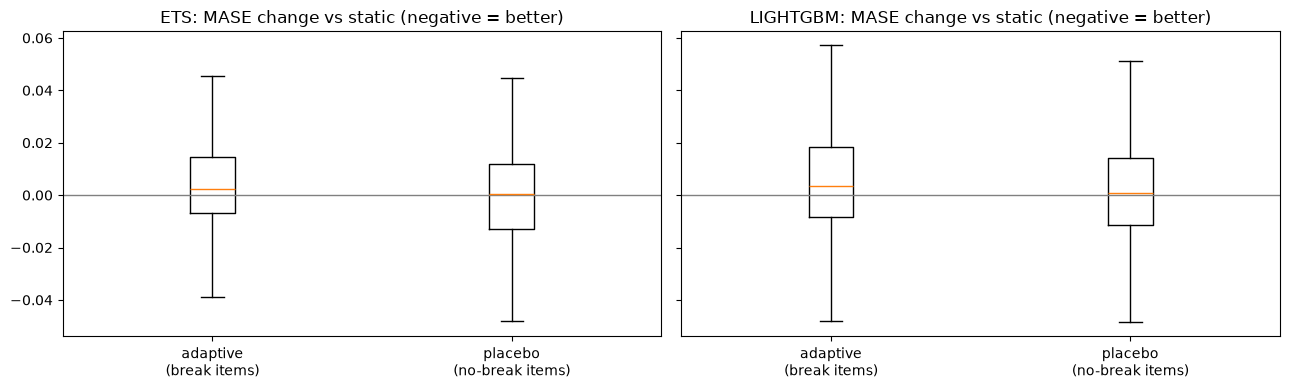

In [9]:
# Is the adaptive gain bigger than the placebo gain? (unpaired: different items)
for model in ['ets', 'lightgbm']:
    a = adapt.loc[adapt['model'] == model, 'diff']
    p = placebo.loc[placebo['model'] == model, 'diff']
    u = stats.mannwhitneyu(a, p)
    print(f"{model}: median adaptive diff {a.median():+.4f} vs placebo {p.median():+.4f}, Mann-Whitney p = {u.pvalue:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, model in zip(axes, ['ets', 'lightgbm']):
    data = [adapt.loc[adapt['model'] == model, 'diff'], placebo.loc[placebo['model'] == model, 'diff']]
    ax.boxplot(data, showfliers=False)
    ax.set_xticks([1, 2], ['adaptive\n(break items)', 'placebo\n(no-break items)'])
    ax.axhline(0, color='grey', lw=1)
    ax.set_title(f"{model.upper()}: MASE change vs static (negative = better)")
plt.tight_layout()
plt.savefig("../outputs/figures/adaptive_vs_placebo.png", dpi=120)
plt.show()

## Result 3: are break items harder to forecast? (selection-bias check)
Items with breaks may differ in volume or variability, so a raw comparison of their error with no-break items is not fair. First check balance (standardized mean differences; |SMD| > 0.1 is usually called imbalance), then regress log static MASE on the break flag **controlling** for those covariates.

In [10]:
pre = long_df[long_df['date'] <= ORIGINS[0]]
cov = pre.groupby('item_id')['sales'].agg(mean_sales='mean', std_sales='std', zero_share=lambda s: (s == 0).mean(),
                                         n_days='size').reset_index()
cov['cv'] = cov['std_sales'] / cov['mean_sales']
cov['category'] = cov['item_id'].map(item_cat)
broke = windows[windows['origin'].isin(EVAL_ORIGINS)].groupby('item_id')['has_break'].any()
cov['break_item'] = cov['item_id'].map(broke)

bal = pd.DataFrame({c: {'break_items_mean': cov.loc[cov['break_item'], c].mean(),
                        'no_break_mean': cov.loc[~cov['break_item'], c].mean(),
                        'SMD': standardized_mean_diff(cov.loc[cov['break_item'], c], cov.loc[~cov['break_item'], c])}
                    for c in ['mean_sales', 'cv', 'zero_share', 'n_days']}).T
print(f"Break items: {cov['break_item'].sum()}, no-break items: {(~cov['break_item']).sum()}")
print(bal.round(3).to_string())

reg = item_mase.merge(cov, on=['item_id', 'category'])
for model in ['ets', 'lightgbm']:
    d = reg[reg['model'] == model].assign(log_mase=lambda x: np.log(x['mase']), log_mean=lambda x: np.log(x['mean_sales']),
                                          break_item=lambda x: x['break_item'].astype(int))
    raw = smf.ols('log_mase ~ break_item', d).fit()
    adj = smf.ols('log_mase ~ break_item + log_mean + cv + zero_share + n_days + C(category)', d).fit()
    for name, m in [('raw', raw), ('adjusted', adj)]:
        lo, hi = m.conf_int().loc['break_item']
        print(f"{model} {name:8s}: break items have {100*(np.exp(m.params['break_item'])-1):+.1f}% MASE "
              f"(95% CI {100*(np.exp(lo)-1):+.1f}% to {100*(np.exp(hi)-1):+.1f}%), p = {m.pvalues['break_item']:.4f}")

Break items: 488, no-break items: 238
            break_items_mean  no_break_mean    SMD
mean_sales            14.605         16.795 -0.115
cv                     0.669          0.663  0.043
zero_share             0.084          0.077  0.096
n_days              1627.074       1486.143  0.448
ets raw     : break items have +0.4% MASE (95% CI -3.6% to +4.6%), p = 0.8472
ets adjusted: break items have +1.6% MASE (95% CI -2.3% to +5.7%), p = 0.4227
lightgbm raw     : break items have +2.0% MASE (95% CI -2.2% to +6.4%), p = 0.3620
lightgbm adjusted: break items have +2.8% MASE (95% CI -1.3% to +7.2%), p = 0.1823


## Uncertainty bands (for the dashboard and notebook 03)
Empirical 90% band per item, model and variant: forecast + 5th / 95th percentile of that item's daily errors from **earlier** origins only (expanding window, starting from the warm-up origin). No band for origin 0.

In [11]:
fc = fc.sort_values(['item_id', 'model', 'variant', 'origin', 'date']).reset_index(drop=True)
fc['error'] = fc['actual'] - fc['forecast']
band_rows = []
for (item, model, variant), g in fc.groupby(['item_id', 'model', 'variant'], sort=False):
    for i, origin in enumerate(ORIGINS[1:], start=1):
        past = g.loc[g['origin'] < origin, 'error']
        band_rows.append((item, model, variant, origin, past.quantile(0.05), past.quantile(0.95), past.std()))
bands = pd.DataFrame(band_rows, columns=['item_id', 'model', 'variant', 'origin', 'err_q05', 'err_q95', 'err_sd'])
fc = fc.merge(bands, on=['item_id', 'model', 'variant', 'origin'], how='left')
fc['lo_90'] = np.maximum(fc['forecast'] + fc['err_q05'], 0)
fc['hi_90'] = fc['forecast'] + fc['err_q95']
fc.to_parquet("../data/processed/backtest_forecasts.parquet", index=False)

cov_ok = fc[fc['origin'].isin(EVAL_ORIGINS)].assign(inside=lambda x: (x['actual'] >= x['lo_90']) & (x['actual'] <= x['hi_90']))
print("Empirical coverage of the nominal 90% band (eval origins):")
print(cov_ok.groupby(['model', 'variant'])['inside'].mean().round(3).unstack().to_string())

Empirical coverage of the nominal 90% band (eval origins):
variant         adaptive  placebo  static
model                                    
ets                0.838    0.840   0.839
lightgbm           0.842    0.844   0.845
seasonal_naive     0.857    0.857   0.857
tsb                0.819    0.816   0.818


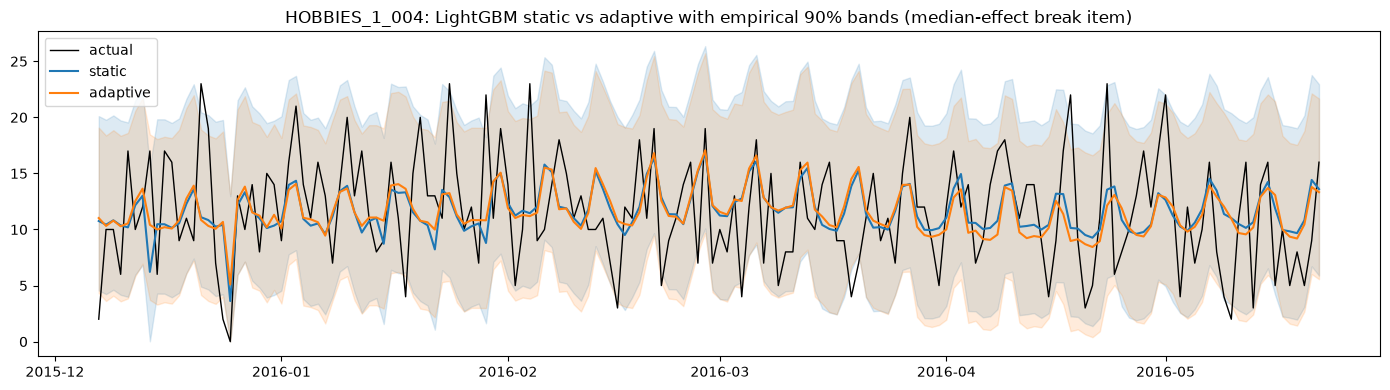

In [12]:
# Example item: actuals vs static & adaptive LightGBM with bands
ex_item = adapt[adapt['model'] == 'lightgbm'].sort_values('diff')['item_id'].iloc[len(adapt[adapt['model'] == 'lightgbm']) // 2]
ex = fc[(fc['item_id'] == ex_item) & (fc['model'] == 'lightgbm') & fc['origin'].isin(EVAL_ORIGINS)]
fig, ax = plt.subplots(figsize=(14, 4))
act = ex[ex['variant'] == 'static']
ax.plot(act['date'], act['actual'], color='black', lw=1, label='actual')
for variant, color in [('static', 'tab:blue'), ('adaptive', 'tab:orange')]:
    e = ex[ex['variant'] == variant]
    ax.plot(e['date'], e['forecast'], color=color, label=variant)
    ax.fill_between(e['date'], e['lo_90'], e['hi_90'], color=color, alpha=0.15)
ax.set_title(f"{ex_item}: LightGBM static vs adaptive with empirical 90% bands (median-effect break item)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/forecast_example_item.png", dpi=120)
plt.show()